In [ ]:
import os
print(os.listdir("/content"))

['.config', 'archive (3).zip', 'sample_data']


In [ ]:
import zipfile

with zipfile.ZipFile("/content/archive (3).zip", "r") as zip_ref:
    zip_ref.extractall("/content")

In [ ]:
print(os.listdir("/content/PlantVillage"))

['Tomato_Spider_mites_Two_spotted_spider_mite', 'Potato___healthy', 'Tomato_healthy', 'Tomato_Late_blight', 'Potato___Early_blight', 'Potato___Late_blight', 'Tomato_Early_blight', 'Tomato__Target_Spot', 'Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Tomato_Septoria_leaf_spot', 'Tomato_Leaf_Mold', 'Tomato_Bacterial_spot', 'Tomato__Tomato_mosaic_virus', 'Tomato__Tomato_YellowLeaf__Curl_Virus']


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    "/content/PlantVillage",   # (we will confirm this)
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training"
)

val_data = datagen.flow_from_directory(
    "/content/PlantVillage",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation"
)

Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.


Found 16516 images belonging to 15 classes.
Found 4122 images belonging to 15 classes.
Classes Found:
{'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1, 'Potato___Early_blight': 2, 'Potato___Late_blight': 3, 'Potato___healthy': 4, 'Tomato_Bacterial_spot': 5, 'Tomato_Early_blight': 6, 'Tomato_Late_blight': 7, 'Tomato_Leaf_Mold': 8, 'Tomato_Septoria_leaf_spot': 9, 'Tomato_Spider_mites_Two_spotted_spider_mite': 10, 'Tomato__Target_Spot': 11, 'Tomato__Tomato_YellowLeaf__Curl_Virus': 12, 'Tomato__Tomato_mosaic_virus': 13, 'Tomato_healthy': 14}


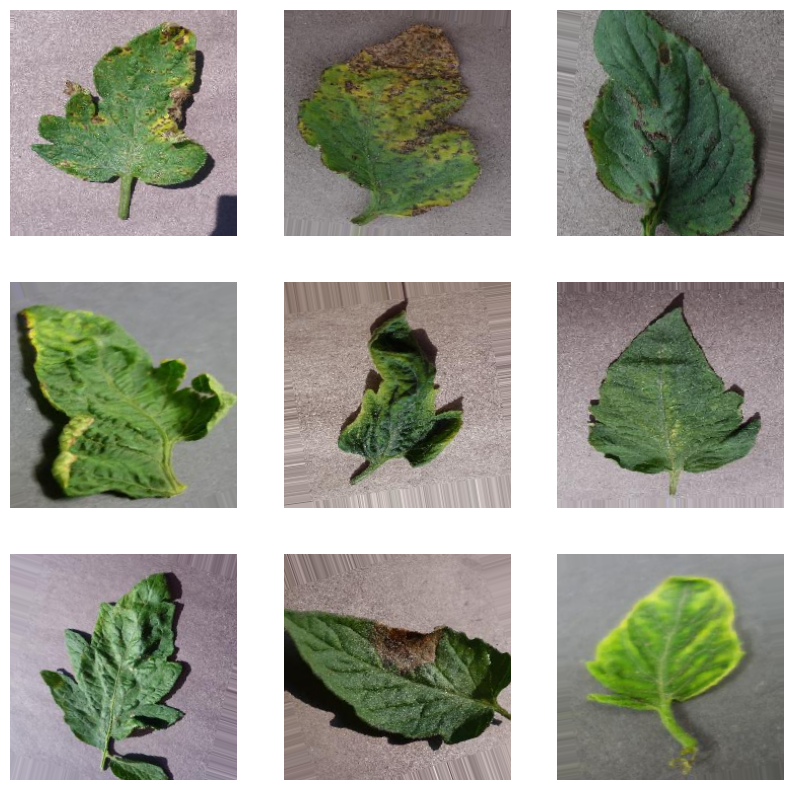

Image Batch Shape: (32, 224, 224, 3)
Label Batch Shape: (32, 15)


In [ ]:
#WEEK 1 - DATA PREPROCESSING

#STEP 1 : IMPORT LIBRARIES

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

#STEP 2 : DATASET PATH

dataset_path = "/content/PlantVillage"

 #STEP 3 : IMAGE SETTINGS

IMG_SIZE = 224
BATCH_SIZE = 32

 #STEP 4 : DATA AUGMENTATION

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)


#STEP 5 : LOAD TRAINING DATA


train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

#STEP 6 : LOAD VALIDATION DATA

val_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

#STEP 7 : DISPLAY CLASSES


print("Classes Found:")
print(train_data.class_indices)

#STEP 8 : VISUALIZE SAMPLE IMAGES


images, labels = next(train_data)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

#STEP 9 : CHECK DATA SHAPE


print("Image Batch Shape:", images.shape)
print("Label Batch Shape:", labels.shape)